In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Additional required libraries
import seaborn as sns
import pandasql as ps
import matplotlib.pyplot as plt

import sqlite3
#import sqlalchemy
from datetime import datetime
from IPython.core.magic import register_line_magic
from sqlalchemy import create_engine

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/airlines-dataset/travel.sqlite


# Introduction

This notebook showcases my analysis of an SQLite dataset using pure SQL and Python libraries. The process involves data cleaning, exploratory data analysis (EDA), table joins, and aggregations to extract meaningful patterns. Lastly, I employ insightful visualizations to highlight key findings and trends, ensuring a comprehensive understanding of the dataset.

# Install jupySQL

JupySQL is a Jupyter Notebook extension that enables running SQL queries directly within notebooks. It helps integrate SQL with Python workflows and supports the use of %sql and %%sql magic commands, which I shall be using in this analysis.

In [2]:
# Importing required libraries
#import sqlite3
#import numpy as np
#import pandas as pd
#import seaborn as sns
#import pandasql as ps
#import matplotlib.pyplot as plt
#import os
#from datetiimport create_engine
#import sqlalchemyme import datetime
#from IPython.core.magic import register_line_magic
#from sqlalchemy 

In [3]:
!pip install jupysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 4.5 MB/s eta 0:00:00


# Create SQLITE Connection Function

In [4]:
def sqliteConnections():
    try:        
        sqlitedb_path = "/kaggle/input/airlines-dataset/travel.sqlite"
        with sqlite3.connect(sqlitedb_path) as sqliteConn:
            engine = create_engine(f"sqlite:////{sqlitedb_path}", echo=True) 
            print("✅ Connection Successful")
            return sqliteConn, engine  
        
    except sqlite3.Error as e:
        print(f"❌ Error Connecting to .db: {e}")
        return None, None

In [5]:
# CONNECTIONS
sqlite_conn, engine = sqliteConnections()

✅ Connection Successful


In [6]:
%load_ext sql

In [7]:
%sql sqlite:////kaggle/input/airlines-dataset/travel.sqlite

Connecting to 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

# Programmatic Assessment

* Load SQL tables

In [8]:
%%sql
SELECT name FROM sqlite_schema WHERE type ='table';

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

name
aircrafts_data
airports_data
boarding_passes
bookings
flights
seats
ticket_flights
tickets


* Load Aircrafts Dataset and

  Extract the english name from model

In [9]:
%%sql 
SELECT * 
FROM aircrafts_data 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

aircraft_code,model,range
773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суперджет-100""}",3000
320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-200""}",5700
321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-200""}",5600


In [10]:
%%sql
SELECT aircraft_code, 
    json_extract(model, '$.en') AS aircraft_model, 
    range
FROM aircrafts_data
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

aircraft_code,aircraft_model,range
773,Boeing 777-300,11100
763,Boeing 767-300,7900
SU9,Sukhoi Superjet-100,3000
320,Airbus A320-200,5700
321,Airbus A321-200,5600


* Load Airports Dataset and
  
Extract english airport name and city name

In [11]:
%%sql
SELECT airport_code, 
        json_extract(airport_name, '$.en') AS airport_name, 
        json_extract(city, '$.en') AS city, 
        coordinates, timezone
FROM airports_data 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

airport_code,airport_name,city,coordinates,timezone
YKS,Yakutsk Airport,Yakutsk,"(129.77099609375,62.0932998657226562)",Asia/Yakutsk
MJZ,Mirny Airport,Mirnyj,"(114.03900146484375,62.534698486328125)",Asia/Yakutsk
KHV,Khabarovsk-Novy Airport,Khabarovsk,"(135.18800354004,48.5279998779300001)",Asia/Vladivostok
PKC,Yelizovo Airport,Petropavlovsk,"(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
UUS,Yuzhno-Sakhalinsk Airport,Yuzhno-Sakhalinsk,"(142.718002319335938,46.8886985778808594)",Asia/Sakhalin


* Load Boarding-passes Dataset and check for duplicates

In [12]:
%%sql
# load boarding-passes data
SELECT *
FROM boarding_passes 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

ticket_no,flight_id,boarding_no,seat_no
0005435212351,30625,1,2D
0005435212386,30625,2,3G
0005435212381,30625,3,4H
0005432211370,30625,4,5D
0005435212357,30625,5,11A


In [13]:
%%sql
# check for duplicate ticket numbers
SELECT 
        COUNT(ticket_no) AS total, 
        COUNT(DISTINCT ticket_no) AS unique_tickets,
        COUNT(ticket_no) - COUNT(DISTINCT ticket_no) AS dup_tickets
FROM boarding_passes;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

total,unique_tickets,dup_tickets
579686,238834,340852


* Load Bookings Dataset and check duplicates

In [14]:
%%sql
# load bookings data
SELECT *
FROM bookings 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

book_ref,book_date,total_amount
00000F,2017-07-05 03:12:00+03,265700
000012,2017-07-14 09:02:00+03,37900
000068,2017-08-15 14:27:00+03,18100
000181,2017-08-10 13:28:00+03,131800
0002D8,2017-08-07 21:40:00+03,23600


In [15]:
%%sql
# check for duplicate bookings references
SELECT 
        COUNT(book_ref) AS total, 
        COUNT(DISTINCT book_ref) unique_ref,
        COUNT(book_ref) - COUNT(DISTINCT book_ref) AS dup_ref
FROM bookings;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

total,unique_ref,dup_ref
262788,262788,0


* Load Flights Dataset and Filter missing data

In [16]:
%%sql
# load flights data
SELECT *
FROM flights 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N


In [17]:
%%sql
# load flights data
SELECT *
FROM flights
WHERE actual_departure != "\N" OR actual_arrival != "\N"
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
1,PG0405,2017-07-16 09:35:00+03,2017-07-16 10:30:00+03,DME,LED,Arrived,321,2017-07-16 09:44:00+03,2017-07-16 10:39:00+03
2,PG0404,2017-08-05 19:05:00+03,2017-08-05 20:00:00+03,DME,LED,Arrived,321,2017-08-05 19:06:00+03,2017-08-05 20:01:00+03
3,PG0405,2017-08-05 09:35:00+03,2017-08-05 10:30:00+03,DME,LED,Arrived,321,2017-08-05 09:39:00+03,2017-08-05 10:34:00+03
14,PG0402,2017-08-06 12:25:00+03,2017-08-06 13:20:00+03,DME,LED,Arrived,321,2017-08-06 12:28:00+03,2017-08-06 13:23:00+03
15,PG0402,2017-07-28 12:25:00+03,2017-07-28 13:20:00+03,DME,LED,Arrived,321,2017-07-28 12:31:00+03,2017-07-28 13:26:00+03


* Load Seats Dataset

In [18]:
%%sql
# load seats descriptions
SELECT *
FROM seats 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

aircraft_code,seat_no,fare_conditions
319,2A,Business
319,2C,Business
319,2D,Business
319,2F,Business
319,3A,Business


* Load Ticket Flights Dataset

In [19]:
%%sql
# load ticket_flights data
SELECT *
FROM ticket_flights 
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

ticket_no,flight_id,fare_conditions,amount
0005432159776,30625,Business,42100
0005435212351,30625,Business,42100
0005435212386,30625,Business,42100
0005435212381,30625,Business,42100
0005432211370,30625,Business,42100


* Load Tickets Dataset

In [20]:
%%sql
# load tickets data
SELECT *
FROM tickets
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

ticket_no,book_ref,passenger_id
0005432000987,06B046,8149 604011
0005432000988,06B046,8499 420203
0005432000989,E170C3,1011 752484
0005432000990,E170C3,4849 400049
0005432000991,F313DD,6615 976589


# ANALYSES AND INSIGHTS:

* Arrived – successful flight.
* Cancelled – flight called off and will not operate. No flight, ignore!
* Delayed – flight is behind scheduled in terms of departure or arrival time. No departure and arrival dates for delayed flights in the data, ignore!
* Departed – aircraft is en route to its destination.
* On Time – flight without delays.
* Scheduled – flight is planned but has not yet departed, ignore!
  
* Flight No - is a specific airline route for a particular flight e.g., New York to Los Angeles.

In all these analyses, I shall use status as 'Arrived', 'On Time', and 'Departed'

# Insight 1. Total Revenue by Booking Date Across Different Fare Conditions

In [22]:
%%sql
-- Total Revenue Collected by Booking Date Across Different Fare Conditions
SELECT 
        DATE(strftime('%Y-%m-%d', datetime(tb.BookingDate))) AS booking_date,
        tb.fare_conditions,
        SUM(tb.total_amount) AS total_revenue
FROM (
        SELECT 
                datetime(substr(b.book_date, 1, 19)) AS BookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
WHERE tb.fare_conditions IN ('Comfort', 'Economy', 'Business')
GROUP BY booking_date
LIMIT 5;

Running query in 'sqlite:////kaggle/input/airlines-dataset/travel.sqlite'

booking_date,fare_conditions,total_revenue
2017-06-21,Economy,3456400
2017-06-22,Business,5244800
2017-06-23,Economy,11122200
2017-06-24,Economy,32406400
2017-06-25,Comfort,81789200


In [23]:
query="""
SELECT 
        DATE(strftime('%Y-%m-%d', datetime(tb.BookingDate))) AS booking_date,
        tb.fare_conditions,
        SUM(tb.total_amount) AS total_revenue
FROM (
        SELECT
                datetime(substr(b.book_date, 1, 19)) AS BookingDate,
                tf.fare_conditions,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
        JOIN ticket_flights tf
        ON t.ticket_no = tf.ticket_no
) AS tb
WHERE tb.fare_conditions IN ('Comfort', 'Economy', 'Business') 
GROUP BY booking_date;
"""
df=pd.read_sql_query(query, sqlite_conn)

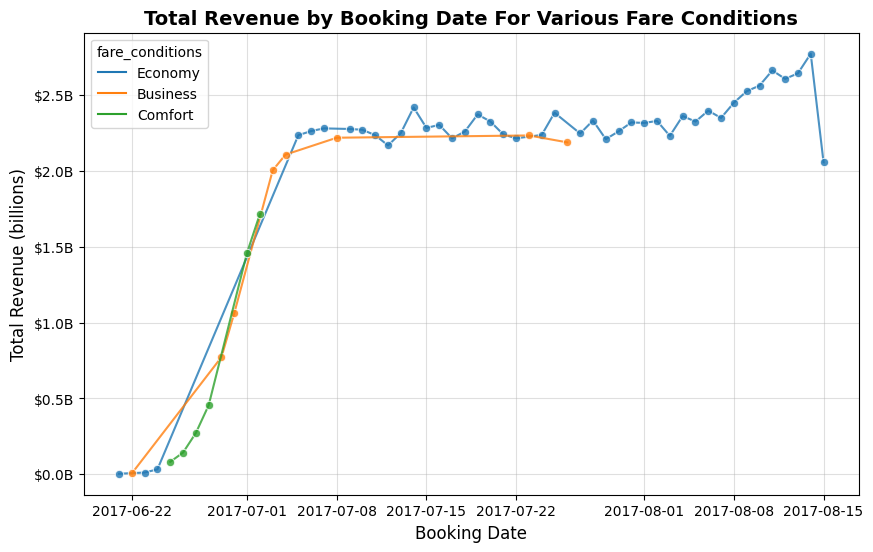

In [24]:
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Data
df['booking_date'] = pd.to_datetime(df['booking_date'])
# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='booking_date', y='total_revenue', hue='fare_conditions', 
             alpha=0.8, marker='o', errorbar=None) 
plt.gca().yaxis.set_major_formatter(lambda x, _: f'${x/1e9:.1f}B')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='-', alpha=0.4)
plt.grid(axis='x', linestyle='-', alpha=0.4)
plt.xlabel('Booking Date', fontsize=12)
plt.ylabel('Total Revenue (billions)', fontsize=12)
plt.title('Total Revenue by Booking Date For Various Fare Conditions', fontsize=14, fontweight='bold')
#plt.xlim(pd.to_datetime('2017-06-15'), pd.to_datetime('2017-08-01')) # try this date range
plt.show();

# Insight 2. Aircraft model with the highest average revenue per fare condition

In [25]:
query="""
SELECT 
        fa.fare_conditions,
        fa.aircraft_model,
        AVG(fa.amount) AS average_revenue
FROM (
        SELECT 
                f.aircraft_code,
                f.flight_no,
                Json_extract(ac.model, '$.en') AS aircraft_model,
                tf.fare_conditions,
                tf.amount
        FROM flights f
        JOIN aircrafts_data ac
        ON f.aircraft_code = ac.aircraft_code
        JOIN ticket_flights tf
        ON f.flight_id = tf.flight_id
        WHERE status IN ('Arrived', 'On Time', 'Departed')
) AS fa

GROUP BY fa.fare_conditions
ORDER BY 3 DESC;
"""
df=pd.read_sql_query(query, sqlite_conn)

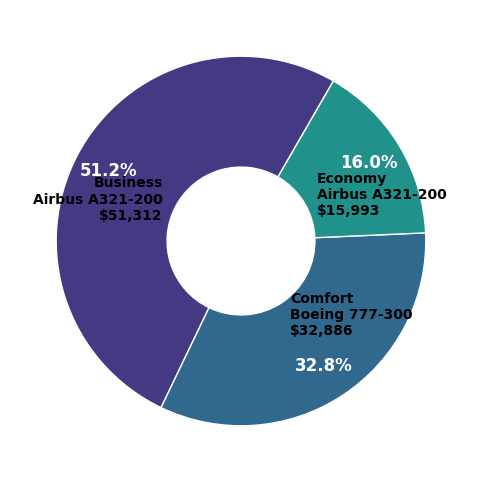

In [26]:
# Create labels with fare conditions, aircraft model, and revenue
labels = [f"{row['fare_conditions']}\n{row['aircraft_model']}\n${row['average_revenue']:,.0f}" for space ,row in df.iterrows()]

# Create plot
plt.figure(figsize=(6, 6))
widgets, texts, autotexts=plt.pie(df['average_revenue'], 
                                labels=labels,
                                autopct='%1.1f%%', 
                                startangle=60,
                                colors=sns.color_palette('viridis', 5),
                                wedgeprops=dict(width=0.6, edgecolor='w'),
                                textprops={'fontsize': 10, 'weight': 'bold'}, 
                                shadow=False,
                                labeldistance=0.48, 
                                pctdistance=0.81 
                                )  

# Customize percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.show();

# Insight 1. Top 10 Airports with the Most Delays

In [ ]:
%%sql
WITH flight_data AS (
       SELECT 
            f.flight_id,
            f.flight_no,
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.scheduled_arrival, 1, 19)) AS scheduled_arrival,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
            f.status,
            json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
            json_extract(ap1.city, '$.en') AS departure_city,
            json_extract(ap2.airport_name, '$.en') AS arrival_airport_name,
            json_extract(ap2.city, '$.en') AS arrival_city
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
        )
SELECT * 
FROM flight_data
WHERE actual_departure !='\\N' OR actual_arrival !='\\N'
LIMIT 5;

In [ ]:
# Top 10 Airports with the Most Delays
querry="""
WITH flight_data AS (
       SELECT 
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
            json_extract(ap1.airport_name, '$.en') AS departure_airport_name
                
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT departure_airport_name, 
        ROUND(AVG(strftime('%s', datetime(actual_departure)) - strftime('%s', datetime(scheduled_departure)))/60,2) AS 'avg_delay (minutes)'
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_airport_name
ORDER BY 2 DESC
LIMIT 10;
"""
df = pd.read_sql_query(querry, sqlite_conn)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=df['avg_delay (minutes)'], y=df['departure_airport_name'], palette='viridis')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Add labels and title
plt.xlabel('Average Delay (minutes)', fontsize=12)
plt.ylabel('Airport Name', fontsize=12)
plt.title('Top 10 Airports with Highest Departure Delays', fontsize=16, fontweight='bold')

# Show the plot
plt.show();

# Insight 2. Flight Status Distribution

In [ ]:
# Flight Status Distribution
querry="""
WITH flight_data AS (
       SELECT 
            f.status
            
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT status, 
        COUNT(*) AS Counts
FROM flight_data
GROUP BY status
ORDER BY 2 DESC;
"""
df=pd.read_sql_query(querry, sqlite_conn)
plt.figure(figsize=(6, 6))
plt.pie(df['Counts'], labels=df['status'], 
        autopct='%1.1f%%', startangle=30, 
        colors=sns.color_palette('viridis', 5),
        wedgeprops=dict(width=0.6, edgecolor='w'),
        textprops={'fontsize': 11},
        shadow=True,
        pctdistance=0.85)

plt.title('Flight Status Distribution', fontsize=16, fontweight='bold')
plt.show();

# Insight 3. Top 10 Most Delayed Flights

In [ ]:
%%sql
-- Top '10' Most Delayed Flights
WITH flight_data AS (
       SELECT 
            f.flight_no,
            json_extract(ap2.city, '$.en') AS arrival_city,
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival
             
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT flight_no, arrival_city,
        ROUND(CAST(strftime('%s', datetime(actual_departure)) - strftime('%s', datetime(scheduled_departure)) AS FLOAT)/3600,2) AS 'delay hours'
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_no 
ORDER BY 3 DESC
LIMIT 10;

In [ ]:
# Top 10 Most Delayed Flights
querry="""
WITH flight_data AS (
       SELECT 
            f.flight_no,
            json_extract(ap2.city, '$.en') AS arrival_city,
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival
             
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT flight_no, arrival_city,
        ROUND(CAST(strftime('%s', datetime(actual_departure)) - strftime('%s', datetime(scheduled_departure)) AS FLOAT)/3600,2) AS 'delay hours'
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_no 
ORDER BY 3 DESC
LIMIT 10;
"""
df=pd.read_sql_query(querry, sqlite_conn)

# Plot
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df, 
    x='flight_no', 
    y='delay hours', 
    hue='arrival_city', 
    palette='viridis', 
    dodge=True, 
    markers='o', 
    linestyles='-'
)

plt.xticks(rotation=45)
plt.xlabel('Flight Number', fontsize=12)
plt.ylabel('Delay Hours', fontsize=12)
plt.title('Flight Delays by Flight Number and Arrival City', fontsize=16, fontweight='bold')
plt.legend(title='Arrival City')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Insight 4. Most Popular Flight Hours

In [ ]:
%%sql
-- Most Popular Flight Hours
WITH flight_data AS (
       SELECT 
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
            json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
            json_extract(ap2.airport_name, '$.en') AS arrival_airport_name
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT strftime('%HH', datetime(scheduled_departure)) AS departure_hour,
        departure_airport_name || ' - ' || arrival_airport_name AS route,
       COUNT(*) AS flight_count

FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_hour
ORDER BY 3 DESC
LIMIT 10;

In [ ]:
# Most Popular Flight Hours
querry="""
WITH flight_data AS (
       SELECT 
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival,
            json_extract(ap1.airport_name, '$.en') AS departure_airport_name,
            json_extract(ap2.airport_name, '$.en') AS arrival_airport_name

        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT strftime('%HH', datetime(scheduled_departure)) AS departure_hour,
       departure_airport_name || ' - ' || arrival_airport_name AS route,
       COUNT(*) AS flight_count
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY departure_hour, route
ORDER BY 3 DESC
LIMIT 10;
"""
df_hour=pd.read_sql_query(querry, sqlite_conn)
# Plot
df_pivot = df_hour.pivot(index='route', columns='departure_hour', values='flight_count').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(df_pivot, cmap='viridis', annot=True, fmt='.0f')

plt.xlabel('Departure Hour', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.title('Heatmap of Flight Frequencies by Route and Departure Hour', fontsize=16, fontweight='bold')

plt.show()

# Insight 5. Peak Travel Days

In [ ]:
%%sql
# Peak Travel Days
WITH flight_data AS (
       SELECT 
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT  
    CASE strftime('%w', scheduled_departure)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS flight_weekday,
       COUNT(*) AS total_flights
    
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_weekday
ORDER BY 2 DESC
LIMIT 10;

In [ ]:
# Peak Travel Days
querry="""
WITH flight_data AS (
       SELECT 
            datetime(substr(f.scheduled_departure, 1, 19)) AS scheduled_departure,
            datetime(substr(f.actual_departure, 1, 19)) AS actual_departure,
            datetime(substr(f.actual_arrival, 1, 19)) AS actual_arrival
        FROM flights f
        JOIN airports_data ap1
        ON f.departure_airport=ap1.airport_code
        JOIN airports_data ap2
        ON f.arrival_airport=ap2.airport_code
)

SELECT  
    CASE strftime('%w', scheduled_departure)
        WHEN '0' THEN 'Sunday'
        WHEN '1' THEN 'Monday'
        WHEN '2' THEN 'Tuesday'
        WHEN '3' THEN 'Wednesday'
        WHEN '4' THEN 'Thursday'
        WHEN '5' THEN 'Friday'
        WHEN '6' THEN 'Saturday'
    END AS flight_weekday,
       COUNT(*) AS total_flights
    
FROM flight_data
WHERE actual_departure !="\\N" OR actual_arrival !="\\N"
GROUP BY flight_weekday
ORDER BY 2 DESC
LIMIT 10;
"""
df_days=pd.read_sql_query(querry, sqlite_conn)

# Plot
plt.figure(figsize=(10, 6))
weekday_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
sns.barplot(data=df_days, x='flight_weekday', y='total_flights', palette='coolwarm', order=weekday_order)

plt.xlabel('Weekday')
plt.ylabel('Total Flights')
plt.title('Total Flights by Weekday and Status')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Airport & Aircraft Utilization-Most Frequently Used Aircrafts-
--# Find out which aircraft models operate the most flights.

In [ ]:
%%sql
-- Top 10 Flight Routes by Total Revenue.
SELECT 
        CASE 
            WHEN fd.departure_city < fd.arrival_city THEN fd.departure_city || ' - ' || fd.arrival_city 
            ELSE fd.arrival_city || ' - ' || fd.departure_city 
            END AS route,
        fd.flight_no,
        Json_extract(ac.model, '$.en') AS aircraft_model,
        SUM(tf.amount) AS total_revenue
FROM (
    WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
    ) fd
JOIN aircrafts_data ac
ON fd.aircraft_code = ac.aircraft_code
JOIN ticket_flights tf
ON fd.flight_id = tf.flight_id
GROUP BY aircraft_model
ORDER BY 4 DESC
LIMIT 10;

In [ ]:
%%sql
SELECT 
        strftime('%Y-%m-%d', datetime(tb.booking_date)) AS booking_weekday,
        COUNT (tb.ticket_no) AS total_tickets,
        SUM(tb.total_amount) AS total_amount
FROM (
        SELECT t.ticket_no,
                t.passenger_id,
                datetime(substr(b.book_date, 1, 19)) AS booking_date,
                b.total_amount
        FROM tickets t
        JOIN bookings b
        ON t.book_ref = b.book_ref
) AS tb
GROUP BY booking_weekday
LIMIT 10;

# Top 10 High-Revenue Flights
--#Calculate how much revenue each flight generates

In [ ]:
%%sql
-- Top 10 High-Revenue Flights
SELECT ac.flight_id, 
        ac.flight_no,
        SUM(ac.amount) AS total_revenue
FROM (
SELECT 
    f.flight_id,
    f.flight_no,
    f.departure_airport,
    f.arrival_airport,
    f.status,
    f.aircraft_code,
    tf.ticket_no,
    tf.fare_conditions,
    tf.amount
FROM flights f
JOIN ticket_flights tf
ON f.flight_id = tf.flight_id
WHERE f.status IN ('Arrived', 'On Time', 'Departed')
) ac
GROUP BY ac.flight_id
ORDER BY total_revenue DESC
LIMIT 10;

# Top 10 Flight Routes by Total Revenue.

--#Revenue by Destination Airport
--#Find out which airports bring in the most revenue.


In [ ]:
%%sql
-- Top 10 Flight Routes by Total Revenue.
SELECT 
        CASE 
            WHEN fd.departure_city < fd.arrival_city THEN fd.departure_city || ' - ' || fd.arrival_city 
            ELSE fd.arrival_city || ' - ' || fd.departure_city 
            END AS route,
        fd.flight_no,
        SUM(tf.amount) AS total_revenue
FROM (
    WITH da AS (
                SELECT airport_code,
                        Json_extract(airports_data.airport_name, '$.en') AS airport_name,
                        Json_extract(airports_data.city, '$.en') AS city
                FROM airports_data
                ),
        df AS (
                SELECT flight_id, 
                        flight_no,
                        departure_airport,
                        arrival_airport,
                        status,
                        aircraft_code
                FROM flights
                WHERE status IN ('Arrived', 'On Time', 'Departed')
                )
        SELECT f.flight_id,
                f.flight_no,
                f.aircraft_code,
                a1.airport_name AS departure_airport,
                a2.airport_name AS arrival_airport,
                a1.city AS departure_city,
                a2.city AS arrival_city,
                f.status
        FROM df f
        JOIN da a1
        ON f.departure_airport = a1.airport_code
        JOIN da a2
        ON f.arrival_airport = a2.airport_code
    ) fd
JOIN ticket_flights tf
ON fd.flight_id = tf.flight_id
GROUP BY route
ORDER BY 3 DESC
LIMIT 10;

In [ ]:
%%sql
SELECT 
        fa.fare_conditions,
        fa.aircraft_model,
        AVG(fa.amount) AS average_revenue
FROM (
        SELECT 
                f.aircraft_code,
                f.flight_no,
                Json_extract(ac.model, '$.en') AS aircraft_model,
                tf.fare_conditions,
                tf.amount
        FROM flights f
        JOIN aircrafts_data ac
        ON f.aircraft_code = ac.aircraft_code
        JOIN ticket_flights tf
        ON f.flight_id = tf.flight_id
        WHERE status IN ('Arrived', 'On Time', 'Departed')
) AS fa

GROUP BY fa.fare_conditions
ORDER BY 3 DESC
LIMIT 10;

Arrived – The aircraft has successfully landed at its destination.
Cancelled – The flight was scheduled but later called off and will not operate.
Delayed – The flight is behind its scheduled departure or arrival time.
Departed – The aircraft has taken off and is en route to its destination.
On Time – The flight is operating as planned without delays.
Scheduled – The flight is planned and listed in the system but has not yet departed.

Flight No (Flight Number):

The flight number is a unique code assigned to a specific airline route for a particular flight. It’s typically a combination of letters (representing the airline) and numbers (identifying the route).
For example, AA100 is American Airlines flight number 100, and it refers to a specific flight on a specific route (e.g., New York to Los Angeles).